# Notebook 5 — Add county-level environmental predictors and compare the model

This notebook extends the FEMA county-level wildfire risk baseline by adding **environmental predictors** from public Google Earth Engine datasets and then re-running the county-level Random Forest baseline.

## Main idea
We already built a county-level model for `log_wildfire_eal` using accessible FEMA/NRI variables.
Now we add wildfire-relevant environmental predictors such as:

- topography:
  - mean elevation
  - mean slope
- land cover:
  - forest fraction
  - shrub fraction
  - grass fraction
  - developed fraction
- climate:
  - warm-season mean maximum temperature
  - warm-season mean precipitation
  - warm-season mean wind speed
  - warm-season mean vapor pressure deficit

## Important scope note
This first environmental augmentation is done for the **contiguous U.S. (CONUS)** only.
That keeps the workflow aligned with directly accessible public layers in Earth Engine, especially GRIDMET and NLCD.

## Files needed in Colab
Upload:
1. `nri_wildfire_county_model_base.csv`

This notebook will generate:
- `county_environmental_predictors_conus.csv`
- `nri_wildfire_county_model_env_conus.csv`
- `wildfire_risk_env_model_results_conus.csv`

In [ ]:
# Optional in Colab:
!pip install -q earthengine-api geemap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ee
import geemap

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)


## Thesis export setup

In [ ]:
# ============================================================
# Thesis export setup for Notebook 5
# Environmental augmentation and model comparison
# ============================================================

from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

EXPORT_DIR = Path("/content/thesis_exports/notebook5_environmental_augmentation_no_titles")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def save_dataframe_as_pdf(df, filename, title="", rows_per_page=25, fontsize=8, fig_width=14):
    """
    Save a pandas DataFrame as a clean multi-page PDF table.
    """
    path = EXPORT_DIR / filename
    df_to_save = df.copy()

    for col in df_to_save.columns:
        if pd.api.types.is_numeric_dtype(df_to_save[col]):
            df_to_save[col] = df_to_save[col].apply(
                lambda x: f"{x:,.4f}" if pd.notna(x) and abs(x) < 100000 else f"{x:,.0f}" if pd.notna(x) else ""
            )
        else:
            df_to_save[col] = df_to_save[col].astype(str)

    with PdfPages(path) as pdf:
        for start in range(0, len(df_to_save), rows_per_page):
            page_df = df_to_save.iloc[start:start + rows_per_page]

            fig_height = max(3.8, 0.42 * len(page_df) + 1.8)
            fig, ax = plt.subplots(figsize=(fig_width, fig_height))
            ax.axis("off")


            table = ax.table(
                cellText=page_df.values,
                colLabels=page_df.columns,
                cellLoc="center",
                loc="center"
            )

            table.auto_set_font_size(False)
            table.set_fontsize(fontsize)
            table.scale(1, 1.30)

            for key, cell in table.get_celld().items():
                cell.set_linewidth(0.4)
                if key[0] == 0:
                    cell.set_text_props(weight="bold")
                    cell.set_facecolor("#eeeeee")

            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved table PDF: {path}")
    return path

def save_current_figure(fig, filename_base):
    """
    Save a matplotlib figure as both PDF and PNG.
    """
    pdf_path = EXPORT_DIR / f"{filename_base}.pdf"
    png_path = EXPORT_DIR / f"{filename_base}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print("Saved figure PDF:", pdf_path)
    print("Saved figure PNG:", png_path)
    return pdf_path, png_path

print("Notebook 5 export directory:", EXPORT_DIR)


## 1. Load the county-level baseline file

In [ ]:
BASE_PATH = "/content/nri_wildfire_county_model_base.csv"

df = pd.read_csv(BASE_PATH, dtype={"county_fips": str})
df["county_fips"] = df["county_fips"].str.zfill(5)

# Drop duplicate text columns if present
drop_cols = [c for c in ["state_pred", "county_pred"] if c in df.columns]
df = df.drop(columns=drop_cols)

print("Base dataframe shape:", df.shape)
display(df.head())


Base dataframe shape: (3144, 15)


,state,county,county_fips,wildfire_eal,log_wildfire_eal,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita
0,Alabama,Autauga,01001,3.626224e+04,10.498560,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078
2,Alabama,Barbour,01005,2.590932e+04,10.162397,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550
3,Alabama,Bibb,01007,3.260612e+04,10.392286,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103
4,Alabama,Blount,01009,9.336726e+04,11.444307,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271


## 2. Restrict to CONUS counties
This first environmental augmentation uses CONUS-friendly public rasters.

In [ ]:
# Exclude Alaska, Hawaii, Puerto Rico, and territories for this first environmental step
EXCLUDE_STATE_FIPS = {"02", "15", "60", "66", "69", "72", "78"}

df["state_fips"] = df["county_fips"].str[:2]
df_conus = df[~df["state_fips"].isin(EXCLUDE_STATE_FIPS)].copy().reset_index(drop=True)

print("Original rows:", len(df))
print("CONUS rows:", len(df_conus))
display(df_conus.head())


Original rows: 3144
CONUS rows: 3109


,state,county,county_fips,wildfire_eal,log_wildfire_eal,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita,state_fips
0,Alabama,Autauga,01001,3.626224e+04,10.498560,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458,01
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078,01
2,Alabama,Barbour,01005,2.590932e+04,10.162397,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550,01
3,Alabama,Bibb,01007,3.260612e+04,10.392286,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103,01
4,Alabama,Blount,01009,9.336726e+04,11.444307,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271,01


## Export: CONUS scope summary

In [ ]:
# ============================================================
# Export Table 1: CONUS scope summary
# ============================================================

conus_scope_summary = pd.DataFrame({
    "Item": [
        "Original baseline county records",
        "CONUS records retained",
        "Records excluded outside CONUS",
        "Excluded state/territory FIPS codes",
        "Reason for CONUS restriction"
    ],
    "Value": [
        len(df),
        len(df_conus),
        len(df) - len(df_conus),
        ", ".join(sorted(EXCLUDE_STATE_FIPS)),
        "Environmental augmentation used CONUS-compatible public raster datasets"
    ]
})

display(conus_scope_summary)

save_dataframe_as_pdf(
    conus_scope_summary,
    filename="table_1_conus_scope_summary.pdf",
    title="Table 1. CONUS Scope Summary for Environmental Augmentation",
    rows_per_page=20,
    fontsize=9,
    fig_width=13
)


## 3. Initialize Earth Engine

In [ ]:
PROJECT_ID = "wildfire-thesis-ml"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")


Earth Engine initialized.


## 4. Build county FeatureCollection from TIGER/2018/Counties
We join by county GEOID/FIPS.

In [ ]:
county_fips_list = df_conus["county_fips"].astype(str).tolist()

counties_fc = (
    ee.FeatureCollection("TIGER/2018/Counties")
    .filter(ee.Filter.inList("GEOID", county_fips_list))
)

print("Requested CONUS counties:", len(county_fips_list))
print("Counties found in EE:", counties_fc.size().getInfo())


Requested CONUS counties: 3109
Counties found in EE: 3100


## 5. Create environmental predictor images
### Public datasets used
- SRTM for elevation/topography
- NLCD 2019 release for land cover
- GRIDMET for warm-season climate

In [ ]:
# ---------- Topography ----------
elevation = ee.Image("USGS/SRTMGL1_003").rename("elevation_m").toDouble()
slope = ee.Terrain.slope(elevation).rename("slope_deg").toDouble()

topo_img = elevation.addBands(slope)

# ---------- Land cover ----------
# NLCD 2019 release: use the 2019 landcover epoch for CONUS
nlcd = (
    ee.ImageCollection("USGS/NLCD_RELEASES/2019_REL/NLCD")
    .filter(ee.Filter.eq("system:index", "2019"))
    .first()
    .select("landcover")
)

forest_mask = nlcd.remap([41, 42, 43], [1, 1, 1], 0).rename("forest_frac").toDouble()
shrub_mask = nlcd.eq(52).rename("shrub_frac").toDouble()
grass_mask = nlcd.remap([71, 81], [1, 1], 0).rename("grass_frac").toDouble()
developed_mask = nlcd.remap([21, 22, 23, 24], [1, 1, 1, 1], 0).rename("developed_frac").toDouble()

landcover_img = (
    forest_mask
    .addBands(shrub_mask)
    .addBands(grass_mask)
    .addBands(developed_mask)
)

# ---------- Climate ----------
# Warm season climatology (May-Oct) over 2016-2020
gridmet = (
    ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")
    .filterDate("2016-01-01", "2021-01-01")
    .filter(ee.Filter.calendarRange(5, 10, "month"))
)

climate_img = (
    gridmet.select("tmmx").mean().subtract(273.15).rename("warm_tmmx_c").toDouble()
    .addBands(gridmet.select("pr").mean().rename("warm_pr_mm").toDouble())
    .addBands(gridmet.select("vs").mean().rename("warm_wind_ms").toDouble())
    .addBands(gridmet.select("vpd").mean().rename("warm_vpd_kpa").toDouble())
)

print("Environmental images prepared.")


Environmental images prepared.


## 6. Reduce predictors by county
We use separate reductions for:
- topography + land cover at finer scale
- climate at GRIDMET scale

In [ ]:
def reduce_fc_to_df(fc, selectors):
    # Convert a small-to-medium EE FeatureCollection to pandas DataFrame.
    data = fc.select(selectors).getInfo()
    rows = []
    for feat in data["features"]:
        rows.append(feat["properties"])
    return pd.DataFrame(rows)

# Topography + land cover
static_fc = topo_img.addBands(landcover_img).reduceRegions(
    collection=counties_fc,
    reducer=ee.Reducer.mean(),
    scale=90
)

# Climate
climate_fc = climate_img.reduceRegions(
    collection=counties_fc,
    reducer=ee.Reducer.mean(),
    scale=4000
)

static_cols = [
    "GEOID",
    "NAME",
    "elevation_m",
    "slope_deg",
    "forest_frac",
    "shrub_frac",
    "grass_frac",
    "developed_frac",
]

climate_cols = [
    "GEOID",
    "NAME",
    "warm_tmmx_c",
    "warm_pr_mm",
    "warm_wind_ms",
    "warm_vpd_kpa",
]

static_df = reduce_fc_to_df(static_fc, static_cols)
climate_df = reduce_fc_to_df(climate_fc, climate_cols)

print("Static DF shape:", static_df.shape)
print("Climate DF shape:", climate_df.shape)

display(static_df.head())
display(climate_df.head())


Static DF shape: (3118, 8)
Climate DF shape: (3118, 6)


,GEOID,NAME,developed_frac,elevation_m,forest_frac,grass_frac,shrub_frac,slope_deg
0,29510,St. Louis,0.925327,148.171960,0.005984,0.005836,0.000222,2.888506
1,32510,Carson City,0.124547,1763.785103,0.123865,0.043551,0.615111,10.266561
2,51580,Covington,0.557836,418.748743,0.341899,0.051351,0.026514,7.506443
3,51530,Buena Vista,0.457978,298.570022,0.393250,0.113282,0.022252,6.951694
4,51678,Lexington,0.900692,323.893650,0.059758,0.031477,0.000000,4.548075


,GEOID,NAME,warm_pr_mm,warm_tmmx_c,warm_vpd_kpa,warm_wind_ms
0,29510,St. Louis,3.624245,27.701225,0.999616,3.727055
1,32510,Carson City,0.397941,24.202117,1.423258,3.825073
2,51580,Covington,3.706314,25.521466,0.762737,3.640092
3,51530,Buena Vista,3.782587,26.451110,0.848846,3.687189
4,51678,Lexington,3.762407,26.771223,0.872950,3.482101


## 7. Merge environmental predictors

In [ ]:
env_df = static_df.merge(
    climate_df.drop(columns=["NAME"]),
    on="GEOID",
    how="inner"
).rename(columns={"GEOID": "county_fips", "NAME": "county_name_ee"})

env_df["county_fips"] = env_df["county_fips"].astype(str).str.zfill(5)

print("Environmental predictor table shape:", env_df.shape)
display(env_df.head())

print("\nMissing values in environmental predictor table:")
print(env_df.isna().sum())


Environmental predictor table shape: (3154, 12)


,county_fips,county_name_ee,developed_frac,elevation_m,forest_frac,grass_frac,shrub_frac,slope_deg,warm_pr_mm,warm_tmmx_c,warm_vpd_kpa,warm_wind_ms
0,29510,St. Louis,0.925327,148.171960,0.005984,0.005836,0.000222,2.888506,3.624245,27.701225,0.999616,3.727055
1,32510,Carson City,0.124547,1763.785103,0.123865,0.043551,0.615111,10.266561,0.397941,24.202117,1.423258,3.825073
2,51580,Covington,0.557836,418.748743,0.341899,0.051351,0.026514,7.506443,3.706314,25.521466,0.762737,3.640092
3,51530,Buena Vista,0.457978,298.570022,0.393250,0.113282,0.022252,6.951694,3.782587,26.451110,0.848846,3.687189
4,51678,Lexington,0.900692,323.893650,0.059758,0.031477,0.000000,4.548075,3.762407,26.771223,0.872950,3.482101



Missing values in environmental predictor table:
county_fips       0
county_name_ee    0
developed_frac    0
elevation_m       0
forest_frac       0
grass_frac        0
shrub_frac        0
slope_deg         0
warm_pr_mm        0
warm_tmmx_c       0
warm_vpd_kpa      0
warm_wind_ms      0
dtype: int64


## Export: Environmental predictor definitions and summaries

In [ ]:
# ============================================================
# Export Table 2: Environmental predictor definitions
# ============================================================

env_predictor_definitions = pd.DataFrame({
    "Predictor": [
        "elevation_m",
        "slope_deg",
        "forest_frac",
        "shrub_frac",
        "grass_frac",
        "developed_frac",
        "warm_tmmx_c",
        "warm_pr_mm",
        "warm_wind_ms",
        "warm_vpd_kpa"
    ],
    "Data source": [
        "SRTM",
        "SRTM-derived terrain",
        "NLCD 2019",
        "NLCD 2019",
        "NLCD 2019",
        "NLCD 2019",
        "gridMET",
        "gridMET",
        "gridMET",
        "gridMET"
    ],
    "County-level aggregation": [
        "Mean over county polygon",
        "Mean over county polygon",
        "Mean binary land-cover fraction",
        "Mean binary land-cover fraction",
        "Mean binary land-cover fraction",
        "Mean binary land-cover fraction",
        "Warm-season mean, then county mean",
        "Warm-season mean, then county mean",
        "Warm-season mean, then county mean",
        "Warm-season mean, then county mean"
    ],
    "Role in wildfire-risk modeling": [
        "Topographic/climatic gradient",
        "Terrain influence on fire behavior",
        "Forest fuel context",
        "Shrub fuel context",
        "Grass/agricultural fuel context",
        "Human/developed-land context",
        "Thermal fire-weather condition",
        "Moisture/fuel-availability condition",
        "Potential fire-spread/suppression condition",
        "Atmospheric dryness/fuel-aridity condition"
    ]
})

display(env_predictor_definitions)

save_dataframe_as_pdf(
    env_predictor_definitions,
    filename="table_2_environmental_predictor_definitions.pdf",
    title="Table 2. Environmental Predictors Added to the County-Level Model",
    rows_per_page=20,
    fontsize=7,
    fig_width=15
)

# ============================================================
# Export Table 3: Environmental predictor summary statistics
# ============================================================

env_numeric_cols = [
    "elevation_m", "slope_deg", "forest_frac", "shrub_frac", "grass_frac",
    "developed_frac", "warm_tmmx_c", "warm_pr_mm", "warm_wind_ms", "warm_vpd_kpa"
]
env_numeric_cols = [c for c in env_numeric_cols if c in env_df.columns]

env_summary_stats = env_df[env_numeric_cols].describe().T.reset_index()
env_summary_stats = env_summary_stats.rename(columns={"index": "Variable"})

display(env_summary_stats)

save_dataframe_as_pdf(
    env_summary_stats,
    filename="table_3_environmental_predictor_summary_statistics.pdf",
    title="Table 3. Summary Statistics of County-Level Environmental Predictors",
    rows_per_page=20,
    fontsize=8,
    fig_width=15
)

# ============================================================
# Export Table 4: Missingness in environmental predictor table
# ============================================================

env_missingness = env_df.isna().sum().reset_index()
env_missingness.columns = ["Variable", "Missing values"]
env_missingness["Missing percentage"] = (env_missingness["Missing values"] / len(env_df) * 100).round(3)

display(env_missingness)

save_dataframe_as_pdf(
    env_missingness,
    filename="table_4_environmental_predictor_missingness.pdf",
    title="Table 4. Missingness in Environmental Predictor Table",
    rows_per_page=30,
    fontsize=8,
    fig_width=12
)


## 8. Merge with the county baseline model table

In [ ]:
model_env_df = df_conus.merge(env_df, on="county_fips", how="left")

print("Merged environmental model dataframe shape:", model_env_df.shape)
display(model_env_df.head())

print("\nMissing values after merge:")
print(model_env_df.isna().sum())


Merged environmental model dataframe shape: (3163, 27)


,state,county,county_fips,wildfire_eal,log_wildfire_eal,population,building_value,agriculture_value,area_sq_mi,social_vulnerability_score,community_resilience_score,population_density,building_value_density,agriculture_value_density,building_value_per_capita,state_fips,county_name_ee,developed_frac,elevation_m,forest_frac,grass_frac,shrub_frac,slope_deg,warm_pr_mm,warm_tmmx_c,warm_vpd_kpa,warm_wind_ms
0,Alabama,Autauga,01001,3.626224e+04,10.498560,58764,1.024141e+10,27630646.0,610.470508,38.040712,55.120865,96.260178,1.677625e+07,45261.229851,174280.275458,01,Autauga,0.064990,112.932212,0.498794,0.210785,0.069525,3.605567,4.283579,30.626405,1.086097,2.892774
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,231365,5.160230e+10,155012958.0,2047.738775,44.243003,93.002545,112.985603,2.519965e+07,75699.576484,223034.170078,01,Baldwin,0.071507,29.697682,0.269194,0.088107,0.037410,1.753440,5.840063,30.504150,0.977747,3.574369
2,Alabama,Barbour,01005,2.590932e+04,10.162397,25160,5.441822e+09,135914589.0,913.646511,96.374046,11.164122,27.538003,5.956157e+06,148760.584468,216288.651550,01,Barbour,0.040160,122.694949,0.565439,0.129400,0.104817,3.277155,4.034570,31.028851,1.124024,2.973741
3,Alabama,Bibb,01007,3.260612e+04,10.392286,22239,3.532631e+09,5410008.0,632.486798,75.254453,22.169211,35.161208,5.585304e+06,8553.550871,158848.459103,01,Bibb,0.051353,130.060354,0.703750,0.101765,0.068850,4.513809,3.721240,30.542362,1.116948,2.954657
4,Alabama,Blount,01009,9.336726e+04,11.444307,58992,8.773489e+09,312712010.0,657.196555,69.338422,15.648855,89.763100,1.334987e+07,475827.220591,148723.370271,01,Blount,0.078889,243.877604,0.551044,0.311285,0.026850,5.688653,3.890174,29.051662,1.006516,2.854285



Missing values after merge:
state                         0
county                        0
county_fips                   0
wildfire_eal                  0
log_wildfire_eal              0
population                    0
building_value                0
agriculture_value             0
area_sq_mi                    0
social_vulnerability_score    0
community_resilience_score    0
population_density            0
building_value_density        0
agriculture_value_density     0
building_value_per_capita     0
state_fips                    0
county_name_ee                9
developed_frac                9
elevation_m                   9
forest_frac                   9
grass_frac                    9
shrub_frac                    9
slope_deg                     9
warm_pr_mm                    9
warm_tmmx_c                   9
warm_vpd_kpa                  9
warm_wind_ms                  9
dtype: int64


## Export: Environmental merge summary

In [ ]:
# ============================================================
# Export Table 5: Environmental merge summary
# ============================================================

env_cols = [
    "elevation_m", "slope_deg", "forest_frac", "shrub_frac", "grass_frac",
    "developed_frac", "warm_tmmx_c", "warm_pr_mm", "warm_wind_ms", "warm_vpd_kpa"
]
env_cols = [c for c in env_cols if c in model_env_df.columns]

rows_with_any_missing_env = int(model_env_df[env_cols].isna().any(axis=1).sum()) if env_cols else 0

env_merge_summary = pd.DataFrame({
    "Item": [
        "CONUS baseline rows before environmental merge",
        "Environmental predictor rows",
        "Rows after merge",
        "Environmental predictor columns added",
        "Rows with any missing environmental predictor",
        "Rows with complete environmental predictor coverage"
    ],
    "Value": [
        len(df_conus),
        len(env_df),
        len(model_env_df),
        len(env_cols),
        rows_with_any_missing_env,
        len(model_env_df) - rows_with_any_missing_env
    ]
})

display(env_merge_summary)

save_dataframe_as_pdf(
    env_merge_summary,
    filename="table_5_environmental_merge_summary.pdf",
    title="Table 5. Environmental Predictor Merge Summary",
    rows_per_page=20,
    fontsize=9,
    fig_width=13
)

# Optional CSV for exact inspection
model_env_df.to_csv(EXPORT_DIR / "nri_wildfire_county_model_env_conus_export_copy.csv", index=False)
print("Saved model_env_df copy:", EXPORT_DIR / "nri_wildfire_county_model_env_conus_export_copy.csv")


## 9. Define feature sets
We compare:
- baseline FEMA/NRI feature set
- environmental-only set
- combined set

In [ ]:
TARGET = "log_wildfire_eal"

baseline_features = [
    "population",
    "building_value",
    "agriculture_value",
    "area_sq_mi",
    "social_vulnerability_score",
    "community_resilience_score",
    "population_density",
    "building_value_density",
    "agriculture_value_density",
    "building_value_per_capita",
]

environmental_features = [
    "elevation_m",
    "slope_deg",
    "forest_frac",
    "shrub_frac",
    "grass_frac",
    "developed_frac",
    "warm_tmmx_c",
    "warm_pr_mm",
    "warm_wind_ms",
    "warm_vpd_kpa",
]

combined_features = baseline_features + environmental_features

feature_sets = {
    "baseline_conus": baseline_features,
    "environmental_only": environmental_features,
    "combined_baseline_plus_environment": combined_features,
}

for name, feats in feature_sets.items():
    print(name, "->", len(feats), "features")


baseline_conus -> 10 features
environmental_only -> 10 features
combined_baseline_plus_environment -> 20 features


## Export: Feature set summary

In [ ]:
# ============================================================
# Export Table 6: Feature set summary
# ============================================================

feature_set_summary = pd.DataFrame({
    "Feature set": list(feature_sets.keys()),
    "Number of features": [len(v) for v in feature_sets.values()],
    "Feature groups": [
        "County exposure, value, vulnerability, resilience",
        "Topography, land cover, warm-season climate",
        "County baseline + environmental predictors"
    ]
})

display(feature_set_summary)

save_dataframe_as_pdf(
    feature_set_summary,
    filename="table_6_feature_set_summary.pdf",
    title="Table 6. Feature Sets Compared in Environmental Augmentation Experiment",
    rows_per_page=20,
    fontsize=8,
    fig_width=13
)


## 10. Model evaluation helper

In [ ]:
def evaluate_models(df_in, feature_cols, target_col=TARGET, random_state=42):
    X = df_in[feature_cols].copy()
    y = df_in[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, feature_cols)
        ]
    )

    models = {
        "RandomForest": RandomForestRegressor(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1,
            max_depth=None,
            min_samples_leaf=2
        ),
        "GradientBoosting": GradientBoostingRegressor(
            random_state=random_state,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3
        )
    }

    rows = []
    fitted = {}

    for model_name, model in models.items():
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
        cv_r2 = cross_val_score(pipe, X, y, cv=kf, scoring="r2", n_jobs=-1)
        cv_mse = -cross_val_score(pipe, X, y, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1)
        cv_rmse = np.sqrt(cv_mse)

        rows.append({
            "model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "CV_R2_mean": cv_r2.mean(),
            "CV_R2_std": cv_r2.std(),
            "CV_RMSE_mean": cv_rmse.mean(),
            "CV_RMSE_std": cv_rmse.std()
        })

        fitted[model_name] = pipe

    return pd.DataFrame(rows).sort_values("CV_R2_mean", ascending=False), fitted


## 11. Run the three comparisons

In [ ]:
all_results = []
fitted_models = {}

for fs_name, feats in feature_sets.items():
    res_df, fitted = evaluate_models(model_env_df, feats)
    res_df.insert(0, "feature_set", fs_name)
    all_results.append(res_df)
    fitted_models[fs_name] = fitted

results_df = pd.concat(all_results, ignore_index=True)
display(results_df)


,feature_set,model,MAE,RMSE,R2,CV_R2_mean,CV_R2_std,CV_RMSE_mean,CV_RMSE_std
0,baseline_conus,RandomForest,1.286762,1.630689,0.556189,0.520308,0.028177,1.608911,0.026571
1,baseline_conus,GradientBoosting,1.315995,1.648879,0.546233,0.497727,0.036870,1.646036,0.046262
2,environmental_only,RandomForest,0.816802,1.112437,0.793459,0.768480,0.016688,1.117500,0.029882
3,environmental_only,GradientBoosting,0.970029,1.255132,0.737073,0.713029,0.018443,1.244525,0.033968
4,combined_baseline_plus_environment,RandomForest,0.778712,1.011296,0.829308,0.795223,0.021712,1.049171,0.023143
5,combined_baseline_plus_environment,GradientBoosting,0.863502,1.084872,0.803568,0.775603,0.018606,1.099417,0.018020


## Export: Model comparison tables

In [ ]:
# ============================================================
# Export Table 7: Environmental augmentation model comparison
# ============================================================

results_export = results_df.copy().sort_values(["CV_R2_mean", "R2"], ascending=False)

display(results_export)

save_dataframe_as_pdf(
    results_export,
    filename="table_7_environmental_augmentation_model_comparison.pdf",
    title="Table 7. Model Performance After Environmental Augmentation",
    rows_per_page=20,
    fontsize=8,
    fig_width=15
)

results_export.to_csv(EXPORT_DIR / "table_7_environmental_augmentation_model_comparison.csv", index=False)
print("Saved CSV:", EXPORT_DIR / "table_7_environmental_augmentation_model_comparison.csv")

# ============================================================
# Export Table 8: Best model by feature set
# ============================================================

best_by_feature_set = (
    results_df.sort_values("CV_R2_mean", ascending=False)
    .groupby("feature_set", as_index=False)
    .first()
    .sort_values("CV_R2_mean", ascending=False)
)

display(best_by_feature_set)

save_dataframe_as_pdf(
    best_by_feature_set,
    filename="table_8_best_model_by_feature_set.pdf",
    title="Table 8. Best Performing Model for Each Feature Set",
    rows_per_page=20,
    fontsize=8,
    fig_width=15
)

best_by_feature_set.to_csv(EXPORT_DIR / "table_8_best_model_by_feature_set.csv", index=False)
print("Saved CSV:", EXPORT_DIR / "table_8_best_model_by_feature_set.csv")


## 12. Plot comparison

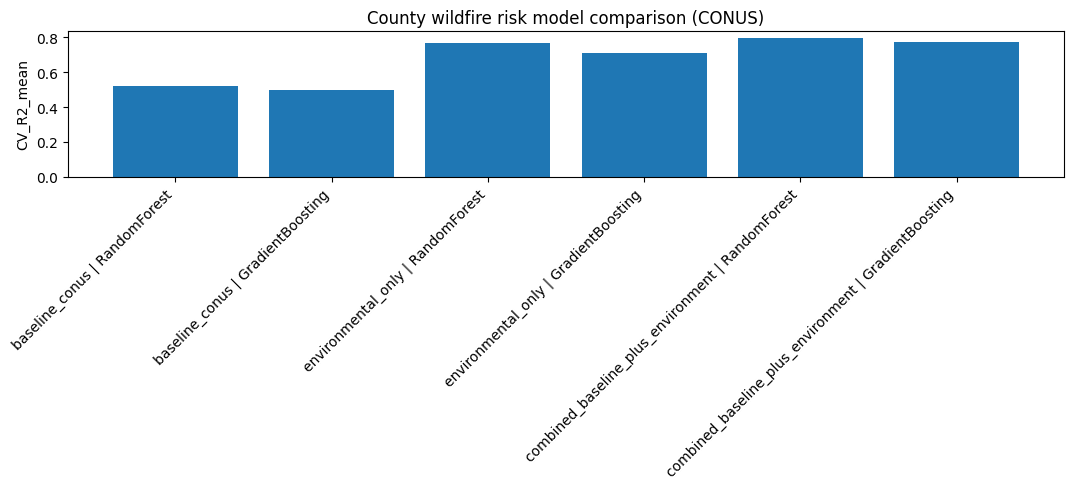

In [ ]:
plot_df = results_df.copy()
plot_df["label"] = plot_df["feature_set"] + " | " + plot_df["model"]

plt.figure(figsize=(11, 5))
plt.bar(plot_df["label"], plot_df["CV_R2_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("CV_R2_mean")
plt.tight_layout()
plt.show()


## Export: Environmental augmentation figures

In [ ]:
# ============================================================
# Export Figure 1: CV R2 model comparison across all feature sets
# ============================================================

plot_df = results_df.copy()
plot_df["label"] = plot_df["feature_set"] + "\n" + plot_df["model"]
plot_df = plot_df.sort_values("CV_R2_mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["label"], plot_df["CV_R2_mean"])
ax.set_xlabel("Mean CV $R^2$", fontsize=11)
ax.set_ylabel("Feature set and model", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

for i, value in enumerate(plot_df["CV_R2_mean"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center", fontsize=9)

ax.set_xlim(0, max(plot_df["CV_R2_mean"]) + 0.10)
plt.tight_layout()
save_current_figure(fig, "figure_1_cv_r2_environmental_augmentation_all_models")
plt.show()

# ============================================================
# Export Figure 2: Random Forest feature-set improvement
# This is the cleanest figure for the main thesis.
# ============================================================

rf_compare = results_df[results_df["model"] == "RandomForest"].copy()
rf_compare = rf_compare.set_index("feature_set").loc[
    ["baseline_conus", "environmental_only", "combined_baseline_plus_environment"]
].reset_index()

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(rf_compare))
width = 0.35

ax.bar(x - width/2, rf_compare["R2"], width, label="Test $R^2$")
ax.bar(x + width/2, rf_compare["CV_R2_mean"], width, label="Mean CV $R^2$")

ax.set_xticks(x)
ax.set_xticklabels(["County-only", "Environmental-only", "Combined"], rotation=0)
ax.set_ylabel("$R^2$", fontsize=11)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

for i, row in rf_compare.iterrows():
    ax.text(i - width/2, row["R2"] + 0.015, f"{row['R2']:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, row["CV_R2_mean"] + 0.015, f"{row['CV_R2_mean']:.3f}", ha="center", fontsize=9)

ax.set_ylim(0, max(rf_compare["R2"].max(), rf_compare["CV_R2_mean"].max()) + 0.12)
plt.tight_layout()
save_current_figure(fig, "figure_2_random_forest_environmental_performance_gain")
plt.show()

# ============================================================
# Export Figure 3: CV RMSE comparison across all feature sets
# ============================================================

plot_df = results_df.copy()
plot_df["label"] = plot_df["feature_set"] + "\n" + plot_df["model"]
plot_df = plot_df.sort_values("CV_RMSE_mean", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["label"], plot_df["CV_RMSE_mean"])
ax.set_xlabel("Mean CV RMSE", fontsize=11)
ax.set_ylabel("Feature set and model", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

for i, value in enumerate(plot_df["CV_RMSE_mean"]):
    ax.text(value + 0.02, i, f"{value:.3f}", va="center", fontsize=9)

ax.set_xlim(0, max(plot_df["CV_RMSE_mean"]) + 0.25)
plt.tight_layout()
save_current_figure(fig, "figure_3_cv_rmse_environmental_augmentation_all_models")
plt.show()


## 13. Inspect feature importance for the combined Random Forest

,feature,importance
17,warm_pr_mm,0.231442
19,warm_vpd_kpa,0.135763
13,shrub_frac,0.093114
3,area_sq_mi,0.079238
1,building_value,0.067090
10,elevation_m,0.062091
0,population,0.053042
11,slope_deg,0.046564
18,warm_wind_ms,0.045235
14,grass_frac,0.036113


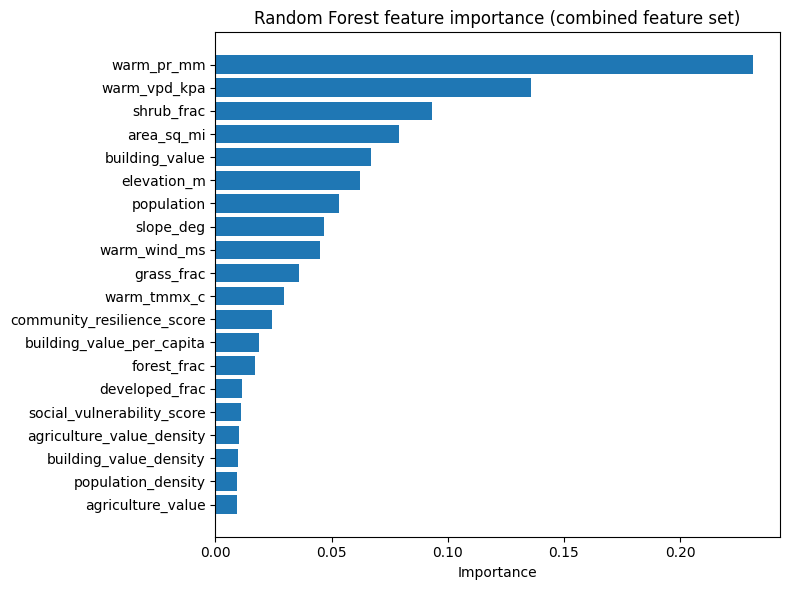

In [ ]:
best_pipe = fitted_models["combined_baseline_plus_environment"]["RandomForest"]
rf_model = best_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": combined_features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## Export: Feature importance and diagnostics

In [ ]:
# ============================================================
# Export Table 9: Combined Random Forest feature importance
# ============================================================

importance_export = importance_df.copy()
display(importance_export)

save_dataframe_as_pdf(
    importance_export,
    filename="table_9_combined_random_forest_feature_importance.pdf",
    title="Table 9. Random Forest Feature Importance for Combined Baseline + Environmental Model",
    rows_per_page=25,
    fontsize=8,
    fig_width=12
)

importance_export.to_csv(EXPORT_DIR / "table_9_combined_random_forest_feature_importance.csv", index=False)
print("Saved CSV:", EXPORT_DIR / "table_9_combined_random_forest_feature_importance.csv")

# ============================================================
# Export Figure 4: Top 15 feature importances
# ============================================================

top_n = min(15, len(importance_df))
plot_imp = importance_df.head(top_n).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_imp["feature"], plot_imp["importance"])
ax.set_xlabel("Feature importance", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

for i, value in enumerate(plot_imp["importance"]):
    ax.text(value + 0.002, i, f"{value:.3f}", va="center", fontsize=9)

ax.set_xlim(0, plot_imp["importance"].max() + 0.04)
plt.tight_layout()
save_current_figure(fig, "figure_4_top15_combined_rf_feature_importance")
plt.show()

# ============================================================
# Export Figure 5: Predicted vs actual for combined Random Forest
# Useful as a diagnostic figure.
# ============================================================

X = model_env_df[combined_features].copy()
y = model_env_df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_pipe = fitted_models["combined_baseline_plus_environment"]["RandomForest"]
y_pred = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_test, y_pred, alpha=0.55)
ax.set_xlabel("Actual log wildfire EAL", fontsize=11)
ax.set_ylabel("Predicted log wildfire EAL", fontsize=11)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
ax.grid(alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
save_current_figure(fig, "figure_5_predicted_vs_actual_combined_rf")
plt.show()


## 14. Save outputs

In [ ]:
ENV_OUT = "/content/county_environmental_predictors_conus.csv"
MODEL_ENV_OUT = "/content/nri_wildfire_county_model_env_conus.csv"
RESULTS_OUT = "/content/wildfire_risk_env_model_results_conus.csv"
IMPORTANCE_OUT = "/content/wildfire_risk_env_feature_importance_conus.csv"

env_df.to_csv(ENV_OUT, index=False)
model_env_df.to_csv(MODEL_ENV_OUT, index=False)
results_df.to_csv(RESULTS_OUT, index=False)
importance_df.to_csv(IMPORTANCE_OUT, index=False)

print("Saved:", ENV_OUT)
print("Saved:", MODEL_ENV_OUT)
print("Saved:", RESULTS_OUT)
print("Saved:", IMPORTANCE_OUT)


Saved: /content/county_environmental_predictors_conus.csv
Saved: /content/nri_wildfire_county_model_env_conus.csv
Saved: /content/wildfire_risk_env_model_results_conus.csv
Saved: /content/wildfire_risk_env_feature_importance_conus.csv
